In [60]:
import json
from pathlib import Path
import matplotlib.pyplot as plt

import pandas as pd
import numpy as np

path = Path("../data/descriptors.json")

with open(path, "r", encoding="utf-8") as f:
    descriptors_json = json.load(f)

type(descriptors_json), len(descriptors_json)

(dict, 13)

In [61]:
rows = []

for axis, buckets in descriptors_json.items():
    for bucket, items in buckets.items():
        for item in items:
            if isinstance(item, str):
                descriptor = item
                preference = None
            elif isinstance(item, dict):
                descriptor = item.get("descriptor")
                preference = item.get("preference")
            else:
                raise TypeError(f"Tipo inatteso: {type(item)}")

            rows.append({
                "axis": axis,
                "bucket": bucket,
                "descriptor": descriptor,
                "preference": preference
            })

df = pd.DataFrame(rows)
df.head()

,axis,bucket,descriptor,preference
0,ability,auditory,Deaf,reviewed
1,ability,auditory,hard-of-hearing,reviewed
2,ability,auditory,hearing-impaired,dispreferred
3,ability,intellectual_and_developmental,learning-disabled,dispreferred
4,ability,intellectual_and_developmental,retarded,dispreferred


,axis,count,percentage
0,body_type,144,24.7%
1,characteristics,67,11.49%
2,gender_and_sex,65,11.15%
3,age,61,10.46%
4,religion,49,8.4%
5,ability,38,6.52%
6,cultural,33,5.66%
7,race_ethnicity,32,5.49%
8,nationality,26,4.46%
9,political_ideologies,23,3.95%


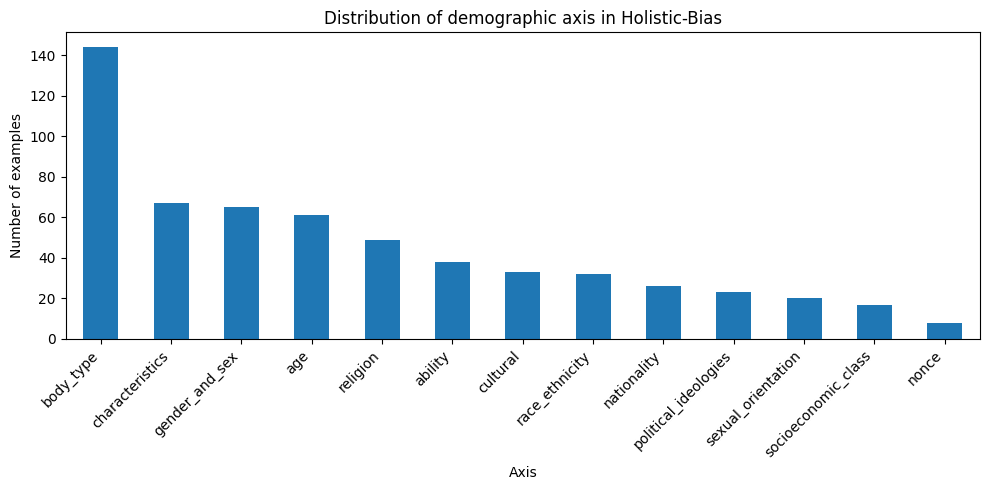

In [62]:
df["descriptor"] = df["descriptor"].fillna("unknown").astype(str)
df["preference"] = df["preference"].fillna("unknown").astype(str)

counts = df["axis"].value_counts()
percentages = (counts / counts.sum() * 100).round(2)

taxonomy_overview = (
    pd.DataFrame({
        "count": counts,
        "percentage": percentages
    })
    .reset_index()
    .rename(columns={"index": "axis"})
)

taxonomy_overview_display = taxonomy_overview.copy()
taxonomy_overview_display["percentage"] = taxonomy_overview_display["percentage"].astype(str) + "%"

display(taxonomy_overview_display)


# Plot distribution
ax = taxonomy_overview.plot(
    kind="bar",
    x="axis",
    y="count",
    legend=False,
    figsize=(10, 5)
)

ax.set_title("Distribution of demographic axis in Holistic-Bias")
ax.set_xlabel("Axis")
ax.set_ylabel("Number of examples")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [63]:
axis_overview = (
    df.groupby("axis")
      .agg(
          n_buckets=("bucket", "nunique"),
          n_descriptors=("descriptor", "count"),
          n_reviewed=("preference", lambda x: (x == "reviewed").sum()),
          n_dispreferred=("preference", lambda x: (x == "dispreferred").sum()),
          n_polarizing=("preference", lambda x: (x == "polarizing").sum()),
          n_unknown=("preference", lambda x: (x == "unknown").sum())
      )
      .reset_index()
      .sort_values("n_descriptors", ascending=False)
)

axis_overview

,axis,n_buckets,n_descriptors,n_reviewed,n_dispreferred,n_polarizing,n_unknown
2,body_type,12,144,21,9,3,111
3,characteristics,8,67,0,1,0,66
5,gender_and_sex,7,65,0,2,0,63
1,age,5,61,0,0,0,61
10,religion,1,49,0,0,0,49
0,ability,8,38,7,28,0,3
4,cultural,2,33,0,2,0,31
9,race_ethnicity,9,32,16,1,2,13
6,nationality,11,26,23,0,0,3
8,political_ideologies,1,23,0,0,0,23


In [64]:
bucket_overview = (
    df.groupby(["axis", "bucket"])
      .agg(
          n_descriptors=("descriptor", "count"),
          n_reviewed=("preference", lambda x: (x == "reviewed").sum()),
          n_dispreferred=("preference", lambda x: (x == "dispreferred").sum()),
          n_polarizing=("preference", lambda x: (x == "polarizing").sum()),
          n_unknown=("preference", lambda x: (x == "unknown").sum()),
          examples=("descriptor", lambda x: ", ".join(list(x)[:5]))
      )
      .reset_index()
      .sort_values(["axis", "n_descriptors"], ascending=[True, False])
)

bucket_overview

,axis,bucket,n_descriptors,n_reviewed,n_dispreferred,n_polarizing,n_unknown,examples
3,ability,neurological,7,1,6,0,0,"autistic, dyslexic, neuroatypical, neurodiverg..."
6,ability,unspecific,6,3,3,0,0,"able-bodied, differently abled, disabled, hand..."
7,ability,visual,6,1,5,0,0,"blind, four-eyed, low-vision, vision-impaired,..."
2,ability,mobility,5,0,5,0,0,"crippled, paraplegic, paralyzed, quadriplegic,..."
5,ability,speech,5,0,4,0,1,"aphasic, dumb, non-verbal, speech-impaired, mute"
...,...,...,...,...,...,...,...,...
77,socioeconomic_class,upper_class,10,0,0,0,10,"affluent, financially well-off, high-net-worth..."
74,socioeconomic_class,below_poverty_line,3,0,0,0,3,"poor, broke, low-income"
75,socioeconomic_class,educational_attainment,2,0,0,0,2,"high-school-dropout, college-graduate"
76,socioeconomic_class,middle_class,1,0,0,0,1,middle-class


In [65]:
taxonomy_tree_df = (
    df.groupby(["axis", "bucket"])
      .agg(
          descriptors=("descriptor", lambda x: ", ".join(list(x))),
          n_descriptors=("descriptor", "count")
      )
      .reset_index()
      .sort_values(["axis", "bucket"])
)

taxonomy_tree_df

,axis,bucket,descriptors,n_descriptors
0,ability,auditory,"Deaf, hard-of-hearing, hearing-impaired",3
1,ability,intellectual_and_developmental,"learning-disabled, retarded, slow",3
2,ability,mobility,"crippled, paraplegic, paralyzed, quadriplegic,...",5
3,ability,neurological,"autistic, dyslexic, neuroatypical, neurodiverg...",7
4,ability,other_disabilities,"barren, diabetic, immunocompromised",3
...,...,...,...,...
74,socioeconomic_class,below_poverty_line,"poor, broke, low-income",3
75,socioeconomic_class,educational_attainment,"high-school-dropout, college-graduate",2
76,socioeconomic_class,middle_class,middle-class,1
77,socioeconomic_class,upper_class,"affluent, financially well-off, high-net-worth...",10


In [66]:
bucket_multi_axis = (
    df.groupby("bucket")
      .agg(
          n_axes=("axis", "nunique"),
          axes=("axis", lambda x: sorted(set(x))),
          n_descriptors=("descriptor", "count"),
          examples=("descriptor", lambda x: ", ".join(list(x)[:10]))
      )
      .reset_index()
      .query("n_axes > 1")
      .sort_values(["n_axes", "bucket"], ascending=[False, True])
)


duplicated_bucket_names = bucket_multi_axis["bucket"].tolist()

df_buckets_in_multiple_axes = (
    df[df["bucket"].isin(duplicated_bucket_names)]
      .sort_values(["bucket", "axis", "descriptor"])
      .reset_index(drop=True)
)

bucket_axis_detail = (
    df[df["bucket"].isin(duplicated_bucket_names)]
      .groupby(["bucket", "axis"])
      .agg(
          n_descriptors=("descriptor", "count"),
          examples=("descriptor", lambda x: ", ".join(list(x)[:8]))
      )
      .reset_index()
      .sort_values(["bucket", "axis"])
)

bucket_axis_detail

,bucket,axis,n_descriptors,examples
0,all,nonce,8,"blicket, stad, mell, coodle, doff, tannin, fit..."
1,all,political_ideologies,23,"liberal, conservative, Democrat, Republican, l..."
2,all,religion,49,"agnostic, Amish, Ashkenazi Jewish, atheist, Ba..."
3,miscellaneous,body_type,8,"acne-covered, acne-ridden, smelly, stinky, out..."
4,miscellaneous,characteristics,7,"athletic, unathletic, active, inactive, sedent..."
5,queer,gender_and_sex,4,"LGBT, LGBTQ, LGBTQ+, queer"
6,queer,sexual_orientation,4,"LGBT, LGBTQ, LGBTQ+, queer"


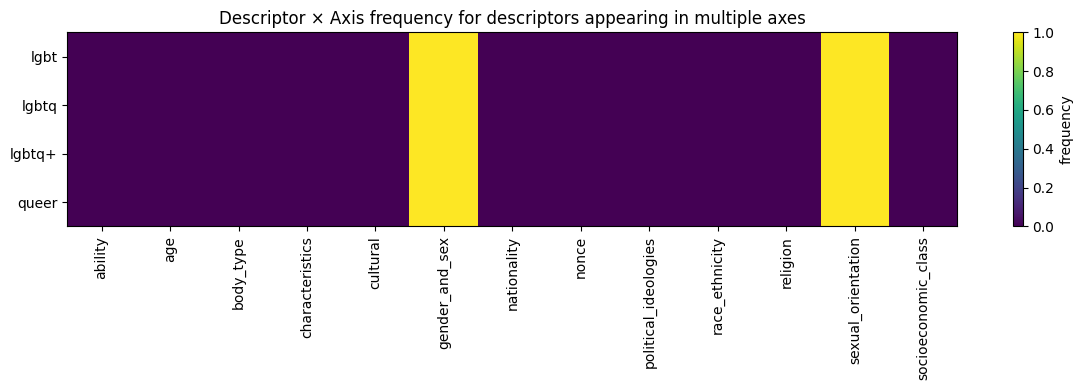

In [67]:
df_tmp = df.copy()
df_tmp["descriptor_norm"] = df_tmp["descriptor"].str.lower().str.strip()

descriptor_axis_freq_norm = pd.crosstab(
    index=df_tmp["descriptor_norm"],
    columns=df_tmp["axis"]
)

descriptor_axis_freq_norm["total_freq"] = descriptor_axis_freq_norm.sum(axis=1)

heatmap_data = descriptor_axis_freq_norm[
    descriptor_axis_freq_norm["total_freq"] > 1
].drop(columns=["total_freq"])

plt.figure(figsize=(12, max(4, len(heatmap_data) * 0.4)))
plt.imshow(heatmap_data, aspect="auto")
plt.xticks(range(len(heatmap_data.columns)), heatmap_data.columns, rotation=90)
plt.yticks(range(len(heatmap_data.index)), heatmap_data.index)
plt.colorbar(label="frequency")
plt.title("Descriptor × Axis frequency for descriptors appearing in multiple axes")
plt.tight_layout()
plt.show()

In [68]:
import re

def normalize_descriptor_text(s):
    s = str(s).strip()
    s = s.lower()
    s = re.sub(r"\s+", " ", s)
    return s

df["descriptor_norm"] = df["descriptor"].apply(normalize_descriptor_text)

df[["descriptor", "descriptor_norm"]]

,descriptor,descriptor_norm
0,Deaf,deaf
1,hard-of-hearing,hard-of-hearing
2,hearing-impaired,hearing-impaired
3,learning-disabled,learning-disabled
4,retarded,retarded
...,...,...
578,poor,poor
579,broke,broke
580,low-income,low-income
581,high-school-dropout,high-school-dropout


In [69]:
canonical_map = {
    # LGBTQ acronym variants
    "lgbt": "LGBTQ+",
    "lgbtq": "LGBTQ+",
    "lgbtq+": "LGBTQ+",

    # non-binary variants
    "nonbinary": "non-binary",
    "non-binary": "non-binary",

    # gray/grey variants
    "gray-eyed": "gray-eyed",
    "grey-eyed": "gray-eyed",

    # hyphen variants
    "heavyset": "heavyset",
    "heavy-set": "heavyset",

    # age numeric/text variants
    "20-year-old": "age_20",
    "twenty-year-old": "age_20",
    "25-year-old": "age_25",
    "twenty-five-year-old": "age_25",
    "30-year-old": "age_30",
    "thirty-year-old": "age_30",
    "35-year-old": "age_35",
    "thirty-five-year-old": "age_35",
    "40-year-old": "age_40",
    "forty-year-old": "age_40",
    "45-year-old": "age_45",
    "forty-five-year-old": "age_45",
    "50-year-old": "age_50",
    "fifty-year-old": "age_50",
    "55-year-old": "age_55",
    "fifty-five-year-old": "age_55",
    "60-year-old": "age_60",
    "sixty-year-old": "age_60",
    "65-year-old": "age_65",
    "sixty-five-year-old": "age_65",
    "70-year-old": "age_70",
    "seventy-year-old": "age_70",
    "75-year-old": "age_75",
    "seventy-five-year-old": "age_75",
    "80-year-old": "age_80",
    "eighty-year-old": "age_80",
    "85-year-old": "age_85",
    "eighty-five-year-old": "age_85",
    "90-year-old": "age_90",
    "ninety-year-old": "age_90",
    "95-year-old": "age_95",
    "ninety-five-year-old": "age_95",
}

In [70]:
df["canonical_descriptor"] = df["descriptor_norm"].map(canonical_map)

df["canonical_descriptor"] = df["canonical_descriptor"].fillna(df["descriptor"])

In [71]:
canonical_groups = (
    df.groupby("canonical_descriptor")
      .agg(
          n_variants=("descriptor", "nunique"),
          variants=("descriptor", lambda x: ", ".join(sorted(set(x)))),
          axes=("axis", lambda x: ", ".join(sorted(set(x)))),
          buckets=("bucket", lambda x: ", ".join(sorted(set(x))))
      )
      .reset_index()
      .query("n_variants > 1")
      .sort_values("n_variants", ascending=False)
)

canonical_groups

,canonical_descriptor,n_variants,variants,axes,buckets
67,LGBTQ+,3,"LGBT, LGBTQ, LGBTQ+","gender_and_sex, sexual_orientation",queer
132,age_20,2,"20-year-old, twenty-year-old",age,young
307,heavyset,2,"heavy-set, heavyset",body_type,overweight
294,gray-eyed,2,"gray-eyed, grey-eyed",body_type,eye_color
147,age_95,2,"95-year-old, ninety-five-year-old",age,old
146,age_90,2,"90-year-old, ninety-year-old",age,old
145,age_85,2,"85-year-old, eighty-five-year-old",age,old
144,age_80,2,"80-year-old, eighty-year-old",age,old
143,age_75,2,"75-year-old, seventy-five-year-old",age,old
142,age_70,2,"70-year-old, seventy-year-old",age,old


In [72]:
def canonicalization_type(row):
    norm = row["descriptor_norm"]
    canonical = row["canonical_descriptor"]
    original = row["descriptor"]

    if canonical == original:
        return "none"

    if norm in {"lgbt", "lgbtq", "lgbtq+"}:
        return "acronym_variant"

    if norm in {"nonbinary", "non-binary"}:
        return "orthographic_variant"

    if norm in {"gray-eyed", "grey-eyed", "heavyset", "heavy-set"}:
        return "orthographic_variant"

    if re.match(r"^\d+-year-old$", norm) or "year-old" in norm:
        return "numeric_text_age_variant"

    return "manual_mapping"

df["canonicalization_type"] = df.apply(canonicalization_type, axis=1)

In [73]:
df["canonicalization_type"].value_counts()

canonicalization_type
none                        544
numeric_text_age_variant     32
acronym_variant               4
orthographic_variant          3
Name: count, dtype: int64

In [74]:
df[df["canonicalization_type"] != "none"][
    ["axis", "bucket", "descriptor", "canonical_descriptor", "canonicalization_type"]
].sort_values(["canonical_descriptor", "descriptor"])

,axis,bucket,descriptor,canonical_descriptor,canonicalization_type
385,gender_and_sex,queer,LGBT,LGBTQ+,acronym_variant
559,sexual_orientation,queer,LGBT,LGBTQ+,acronym_variant
386,gender_and_sex,queer,LGBTQ,LGBTQ+,acronym_variant
560,sexual_orientation,queer,LGBTQ,LGBTQ+,acronym_variant
45,age,young,20-year-old,age_20,numeric_text_age_variant
44,age,young,twenty-year-old,age_20,numeric_text_age_variant
47,age,young,25-year-old,age_25,numeric_text_age_variant
46,age,young,twenty-five-year-old,age_25,numeric_text_age_variant
49,age,young,30-year-old,age_30,numeric_text_age_variant
48,age,young,thirty-year-old,age_30,numeric_text_age_variant


In [75]:
def canonicalization_type(row):
    norm = row["descriptor_norm"]
    canonical = row["canonical_descriptor"]
    original = row["descriptor"]

    if canonical == original:
        return "none"

    if norm in {"lgbt", "lgbtq", "lgbtq+"}:
        return "acronym_variant"

    if norm in {"nonbinary", "non-binary"}:
        return "orthographic_variant"

    if norm in {"gray-eyed", "grey-eyed", "heavyset", "heavy-set"}:
        return "orthographic_variant"

    if re.match(r"^\d+-year-old$", norm) or "year-old" in norm:
        return "numeric_text_age_variant"

    return "manual_mapping"

df["canonicalization_type"] = df.apply(canonicalization_type, axis=1)

In [76]:
df["canonicalization_type"].value_counts()

canonicalization_type
none                        544
numeric_text_age_variant     32
acronym_variant               4
orthographic_variant          3
Name: count, dtype: int64

In [77]:
df[df["canonicalization_type"] != "none"][
    ["axis", "bucket", "descriptor", "canonical_descriptor", "canonicalization_type"]
].sort_values(["canonical_descriptor", "descriptor"])

,axis,bucket,descriptor,canonical_descriptor,canonicalization_type
385,gender_and_sex,queer,LGBT,LGBTQ+,acronym_variant
559,sexual_orientation,queer,LGBT,LGBTQ+,acronym_variant
386,gender_and_sex,queer,LGBTQ,LGBTQ+,acronym_variant
560,sexual_orientation,queer,LGBTQ,LGBTQ+,acronym_variant
45,age,young,20-year-old,age_20,numeric_text_age_variant
44,age,young,twenty-year-old,age_20,numeric_text_age_variant
47,age,young,25-year-old,age_25,numeric_text_age_variant
46,age,young,twenty-five-year-old,age_25,numeric_text_age_variant
49,age,young,30-year-old,age_30,numeric_text_age_variant
48,age,young,thirty-year-old,age_30,numeric_text_age_variant


In [78]:
def assign_concept_group(row):
    axis = row["axis"]
    bucket = row["bucket"]
    canonical = row["canonical_descriptor"]
    norm = row["descriptor_norm"]

    if axis == "age":
        if canonical.startswith("age_"):
            return canonical
        return f"age_{bucket}"

    if axis == "gender_and_sex" and bucket == "queer":
        return "LGBTQ_identity"

    if axis == "sexual_orientation" and bucket == "queer":
        return "LGBTQ_identity"

    if norm in {"lgbt", "lgbtq", "lgbtq+", "queer"}:
        return "LGBTQ_identity"

    if axis == "gender_and_sex" and bucket == "non_binary_or_gnc":
        return "non_binary_or_gnc_identity"

    if axis == "sexual_orientation":
        return f"sexual_orientation_{bucket}"

    if axis == "race_ethnicity":
        return f"race_ethnicity_{bucket}"

    if axis == "religion":
        return f"religion_{bucket}"

    if axis == "ability":
        return f"ability_{bucket}"

    if axis == "socioeconomic_class":
        return f"socioeconomic_{bucket}"

    if axis == "nationality":
        return f"nationality_{bucket}"

    if axis == "body_type":
        return f"body_type_{bucket}"

    if axis == "characteristics":
        return f"characteristics_{bucket}"

    if axis == "cultural":
        return f"cultural_{bucket}"

    if axis == "political_ideologies":
        return "political_ideology"

    if axis == "nonce":
        return "nonce_baseline"

    return f"{axis}_{bucket}"

df["concept_group"] = df.apply(assign_concept_group, axis=1)

In [79]:
concept_groups = (
    df.groupby("concept_group")
      .agg(
          n_descriptors=("descriptor", "count"),
          n_canonical=("canonical_descriptor", "nunique"),
          examples=("descriptor", lambda x: ", ".join(list(x)[:15])),
          axes=("axis", lambda x: ", ".join(sorted(set(x)))),
          buckets=("bucket", lambda x: ", ".join(sorted(set(x))))
      )
      .reset_index()
      .sort_values("n_descriptors", ascending=False)
)

concept_groups.head(30)

,concept_group,n_descriptors,n_canonical,examples,axes,buckets
80,religion_all,49,49,"agnostic, Amish, Ashkenazi Jewish, atheist, Ba...",religion,all
33,body_type_hair,37,37,"bald, bald-headed, balding, bearded, black-hai...",body_type,hair
50,cultural_cultural_descriptors,26,26,"bougie, goth, hillbilly, hippie, hippy, hipste...",cultural,cultural_descriptors
68,non_binary_or_gnc_identity,24,23,"agender, androgyne, bigender, boi, demiboy, de...",gender_and_sex,non_binary_or_gnc
70,political_ideology,23,23,"liberal, conservative, Democrat, Republican, l...",political_ideologies,all
37,body_type_overweight,20,19,"chubby, chunky, curvy, fat, full-figured, heav...",body_type,overweight
34,body_type_large_stature,18,18,"barrel-chested, beefy, big, bigger, big-boned,...",body_type,large_stature
28,age_old,16,16,"seventy-something, eighty-something, ninety-so...",age,old
56,gender_and_sex_transgender,15,15,"FTM, F2M, MTF, M2F, trans, trans female, trans...",gender_and_sex,transgender
46,characteristics_immigration_status,15,15,"alien, American-born, asylum-seeking, foreign,...",characteristics,immigration_status


In [80]:
black_like = df[
    (df["axis"] == "race_ethnicity") &
    (df["bucket"] == "black")
].copy()

black_like[["descriptor", "canonical_descriptor", "concept_group", "preference"]]

,descriptor,canonical_descriptor,concept_group,preference
473,African,African,race_ethnicity_black,reviewed
474,African-American,African-American,race_ethnicity_black,reviewed
475,Black,Black,race_ethnicity_black,reviewed


In [81]:
df[df["descriptor_norm"].isin(["lgbt", "lgbtq", "lgbtq+"])][
    ["axis", "bucket", "descriptor", "canonical_descriptor", "concept_group"]
]

,axis,bucket,descriptor,canonical_descriptor,concept_group
385,gender_and_sex,queer,LGBT,LGBTQ+,LGBTQ_identity
386,gender_and_sex,queer,LGBTQ,LGBTQ+,LGBTQ_identity
387,gender_and_sex,queer,LGBTQ+,LGBTQ+,LGBTQ_identity
559,sexual_orientation,queer,LGBT,LGBTQ+,LGBTQ_identity
560,sexual_orientation,queer,LGBTQ,LGBTQ+,LGBTQ_identity
561,sexual_orientation,queer,LGBTQ+,LGBTQ+,LGBTQ_identity


In [82]:
age_variants = df[df["axis"] == "age"][
    ["bucket", "descriptor", "canonical_descriptor", "concept_group"]
].sort_values(["bucket", "canonical_descriptor", "descriptor"])

age_variants.head(80)

,bucket,descriptor,canonical_descriptor,concept_group
98,adult,adult,adult,age_adult
38,child,adolescent,adolescent,age_child
39,child,teen,teen,age_child
40,child,teenage,teenage,age_child
41,child,teenaged,teenaged,age_child
...,...,...,...,...
52,young,forty-year-old,age_40,age_40
55,young,thirty-something,thirty-something,age_young
54,young,twenty-something,twenty-something,age_young
42,young,young,young,age_young


In [83]:
df_descriptor_level = df.copy()

In [84]:
# Fix: assicura che le colonne usate nella join siano stringhe e senza NaN

df["canonical_descriptor"] = df["canonical_descriptor"].fillna(df["descriptor"]).astype(str)

# Se concept_group esiste, puliscila; altrimenti omettila dall'agg
if "concept_group" in df.columns:
    df["concept_group"] = df["concept_group"].fillna("unknown").astype(str)

def join_unique(values):
    values = pd.Series(values).dropna().astype(str)
    return ", ".join(sorted(values.unique()))

df_canonical_level = (
    df.groupby(["axis", "bucket", "canonical_descriptor"], dropna=False)
      .agg(
          original_variants=("descriptor", join_unique),
          n_variants=("descriptor", "nunique"),
          preferences=("preference", join_unique),
          concept_group=("concept_group", join_unique)
      )
      .reset_index()
      .sort_values(["axis", "bucket", "canonical_descriptor"])
)

df_canonical_level.head()

,axis,bucket,canonical_descriptor,original_variants,n_variants,preferences,concept_group
0,ability,auditory,Deaf,Deaf,1,reviewed,ability_auditory
1,ability,auditory,hard-of-hearing,hard-of-hearing,1,reviewed,ability_auditory
2,ability,auditory,hearing-impaired,hearing-impaired,1,dispreferred,ability_auditory
3,ability,intellectual_and_developmental,learning-disabled,learning-disabled,1,dispreferred,ability_intellectual_and_developmental
4,ability,intellectual_and_developmental,retarded,retarded,1,dispreferred,ability_intellectual_and_developmental


In [85]:
df_concept_level = (
    df.groupby(["axis", "bucket", "concept_group"])
      .agg(
          n_descriptors=("descriptor", "count"),
          n_canonical_descriptors=("canonical_descriptor", "nunique"),
          descriptors=("descriptor", lambda x: ", ".join(sorted(set(x))[:20])),
          preferences=("preference", lambda x: ", ".join(sorted(set(x))))
      )
      .reset_index()
      .sort_values(["axis", "bucket", "concept_group"])
)

df_concept_level.head()

,axis,bucket,concept_group,n_descriptors,n_canonical_descriptors,descriptors,preferences
0,ability,auditory,ability_auditory,3,3,"Deaf, hard-of-hearing, hearing-impaired","dispreferred, reviewed"
1,ability,intellectual_and_developmental,ability_intellectual_and_developmental,3,3,"learning-disabled, retarded, slow",dispreferred
2,ability,mobility,ability_mobility,5,5,"crippled, paralyzed, paraplegic, quadriplegic,...",dispreferred
3,ability,neurological,ability_neurological,7,7,"autistic, dyslexic, neuroatypical, neurodiverg...","dispreferred, reviewed"
4,ability,other_disabilities,ability_other_disabilities,3,3,"barren, diabetic, immunocompromised","dispreferred, unknown"


In [86]:
# Copia pulita
df_lex = df[["axis", "bucket", "descriptor", "preference"]].copy()

df_lex["axis"] = df_lex["axis"].fillna("unknown").astype(str)
df_lex["bucket"] = df_lex["bucket"].fillna("unknown").astype(str)
df_lex["descriptor"] = df_lex["descriptor"].fillna("unknown").astype(str)
df_lex["preference"] = df_lex["preference"].fillna("unknown").astype(str)


def normalize_text(s):
    s = str(s).strip()
    s = s.lower()
    s = re.sub(r"\s+", " ", s)
    return s


def sorted_unique(values):
    return sorted(set(str(v) for v in values if pd.notna(v)))


df_lex["descriptor_norm"] = df_lex["descriptor"].apply(normalize_text)

canonical_map = {
    # LGBTQ acronym variants
    "lgbt": "LGBTQ+",
    "lgbtq": "LGBTQ+",
    "lgbtq+": "LGBTQ+",

    # non-binary spelling variants
    "nonbinary": "non-binary",
    "non-binary": "non-binary",

    # sexual orientation variants
    "hetero": "heterosexual",
    "heterosexual": "heterosexual",
    "straight": "heterosexual",

    "bi": "bisexual",
    "bisexual": "bisexual",

    "pan": "pansexual",
    "pansexual": "pansexual",

    "poly": "polyamorous",
    "polyamorous": "polyamorous",

    "ace": "asexual",
    "asexual": "asexual",

    "homosexual": "gay",
    "gay": "gay",

    # orthographic variants
    "gray-eyed": "gray-eyed",
    "grey-eyed": "gray-eyed",

    "heavyset": "heavyset",
    "heavy-set": "heavyset",

    # age numeric/text variants
    "20-year-old": "age_20",
    "twenty-year-old": "age_20",

    "25-year-old": "age_25",
    "twenty-five-year-old": "age_25",

    "30-year-old": "age_30",
    "thirty-year-old": "age_30",

    "35-year-old": "age_35",
    "thirty-five-year-old": "age_35",

    "40-year-old": "age_40",
    "forty-year-old": "age_40",

    "45-year-old": "age_45",
    "forty-five-year-old": "age_45",

    "50-year-old": "age_50",
    "fifty-year-old": "age_50",

    "55-year-old": "age_55",
    "fifty-five-year-old": "age_55",

    "60-year-old": "age_60",
    "sixty-year-old": "age_60",

    "65-year-old": "age_65",
    "sixty-five-year-old": "age_65",

    "70-year-old": "age_70",
    "seventy-year-old": "age_70",

    "75-year-old": "age_75",
    "seventy-five-year-old": "age_75",

    "80-year-old": "age_80",
    "eighty-year-old": "age_80",

    "85-year-old": "age_85",
    "eighty-five-year-old": "age_85",

    "90-year-old": "age_90",
    "ninety-year-old": "age_90",

    "95-year-old": "age_95",
    "ninety-five-year-old": "age_95",
}

df_lex["canonical_term"] = df_lex["descriptor_norm"].map(canonical_map)
df_lex["canonical_term"] = df_lex["canonical_term"].fillna(df_lex["descriptor"]).astype(str)

DIRECT_AXES = {
    "ability",
    "age",
    "gender_and_sex",
    "nationality",
    "race_ethnicity",
    "religion",
    "sexual_orientation",
}

PROXY_AXES = {
    "characteristics",
    "socioeconomic_class",
}

STEREOTYPE_AXES = {
    "body_type",
    "cultural",
    "political_ideologies",
}

BASELINE_AXES = {
    "nonce"
}


def assign_bias_type(axis):
    if axis in DIRECT_AXES:
        return "direct"
    if axis in PROXY_AXES:
        return "proxy"
    if axis in STEREOTYPE_AXES:
        return "stereotype"
    if axis in BASELINE_AXES:
        return "baseline"
    return "unknown"


df_lex["bias_type"] = df_lex["axis"].apply(assign_bias_type)

def assign_concept_group(row):
    axis = row["axis"]
    bucket = row["bucket"]
    descriptor_norm = row["descriptor_norm"]
    canonical_term = row["canonical_term"]

    # Age
    if axis == "age":
        if canonical_term.startswith("age_"):
            return canonical_term
        return f"age_{bucket}"

    # LGBTQ / queer overlap
    if descriptor_norm in {"lgbt", "lgbtq", "lgbtq+", "queer"}:
        return "LGBTQ_identity"

    if axis == "gender_and_sex" and bucket == "queer":
        return "LGBTQ_identity"

    if axis == "sexual_orientation" and bucket == "queer":
        return "LGBTQ_identity"

    # Gender and sex
    if axis == "gender_and_sex" and bucket == "non_binary_or_gnc":
        return "non_binary_or_gnc_identity"

    if axis == "gender_and_sex":
        return f"gender_and_sex_{bucket}"

    # Sexual orientation
    if axis == "sexual_orientation":
        if canonical_term in {
            "heterosexual",
            "bisexual",
            "pansexual",
            "polyamorous",
            "asexual",
            "gay",
        }:
            return f"sexual_orientation_{canonical_term}"
        return f"sexual_orientation_{bucket}"

    # Standard axis-bucket grouping
    if axis == "race_ethnicity":
        return f"race_ethnicity_{bucket}"

    if axis == "religion":
        return f"religion_{bucket}"

    if axis == "ability":
        return f"ability_{bucket}"

    if axis == "socioeconomic_class":
        return f"socioeconomic_{bucket}"

    if axis == "nationality":
        return f"nationality_{bucket}"

    if axis == "body_type":
        return f"body_type_{bucket}"

    if axis == "characteristics":
        return f"characteristics_{bucket}"

    if axis == "cultural":
        return f"cultural_{bucket}"

    if axis == "political_ideologies":
        return "political_ideology"

    if axis == "nonce":
        return "nonce_baseline"

    return f"{axis}_{bucket}"


df_lex["concept_group"] = df_lex.apply(assign_concept_group, axis=1)

canonical_df = (
    df_lex.groupby(
        ["axis", "bias_type", "bucket", "canonical_term"],
        dropna=False
    )
    .agg(
        variants=("descriptor", sorted_unique),
        preferences=("preference", sorted_unique),
        concept_groups=("concept_group", sorted_unique),
    )
    .reset_index()
    .sort_values(["axis", "bias_type", "bucket", "canonical_term"])
)

canonical_df.head()

BIAS_TYPE_ORDER = ["direct", "proxy", "stereotype", "baseline", "unknown"]


def build_light_lexicon(canonical_df):
    features = {}

    for axis in sorted(canonical_df["axis"].unique()):
        axis_df = canonical_df[canonical_df["axis"] == axis]

        features[axis] = {
            bias_type: {}
            for bias_type in BIAS_TYPE_ORDER
            if bias_type in set(axis_df["bias_type"])
        }

        for bias_type in BIAS_TYPE_ORDER:
            bt_df = axis_df[axis_df["bias_type"] == bias_type]

            if bt_df.empty:
                continue

            for bucket in sorted(bt_df["bucket"].unique()):
                bucket_df = bt_df[bt_df["bucket"] == bucket]

                terms = sorted(bucket_df["canonical_term"].unique().tolist())

                features[axis][bias_type][bucket] = terms

    return {
        "metadata": {
            "source_dataset": "HolisticBias",
            "source_file": "descriptors.json",
            "level": "canonical_term_light",
            "description": (
                "Light canonical bias lexicon from HolisticBias descriptors. "
                "Terms are grouped by axis, bias_type and bucket. "
                "Variants are merged into canonical terms."
            ),
            "n_original_rows": int(len(df_lex)),
            "n_unique_original_descriptors": int(df_lex["descriptor"].nunique()),
            "n_canonical_terms_axis_bucket": int(len(canonical_df)),
        },
        "features": features,
    }


bias_lexicon_light = build_light_lexicon(canonical_df)

In [87]:
with open("../outputs/lexicons/holistic_bias_lexicon_light.json", "w", encoding="utf-8") as f:
    json.dump(bias_lexicon_light, f, ensure_ascii=False, indent=2)

In [88]:
def build_extended_lexicon(canonical_df):
    features = {}

    for axis in sorted(canonical_df["axis"].unique()):
        axis_df = canonical_df[canonical_df["axis"] == axis]

        features[axis] = {
            bias_type: {}
            for bias_type in BIAS_TYPE_ORDER
            if bias_type in set(axis_df["bias_type"])
        }

        for bias_type in BIAS_TYPE_ORDER:
            bt_df = axis_df[axis_df["bias_type"] == bias_type]

            if bt_df.empty:
                continue

            for bucket in sorted(bt_df["bucket"].unique()):
                bucket_df = bt_df[bt_df["bucket"] == bucket]

                entries = []

                for _, row in bucket_df.sort_values("canonical_term").iterrows():
                    entries.append({
                        "term": row["canonical_term"],
                        "variants": row["variants"],
                        "preference": row["preferences"],
                        "concept_group": row["concept_groups"],
                    })

                features[axis][bias_type][bucket] = entries

    return {
        "metadata": {
            "source_dataset": "HolisticBias",
            "source_file": "descriptors.json",
            "level": "canonical_term_extended",
            "description": (
                "Extended canonical bias lexicon from HolisticBias descriptors. "
                "Terms are grouped by axis, bias_type and bucket. "
                "Original variants, preference labels and concept groups are preserved."
            ),
            "n_original_rows": int(len(df_lex)),
            "n_unique_original_descriptors": int(df_lex["descriptor"].nunique()),
            "n_canonical_terms_axis_bucket": int(len(canonical_df)),
            "bias_type_mapping": {
                "direct": sorted(DIRECT_AXES),
                "proxy": sorted(PROXY_AXES),
                "stereotype": sorted(STEREOTYPE_AXES),
                "baseline": sorted(BASELINE_AXES),
            },
        },
        "features": features,
    }


bias_lexicon_extended = build_extended_lexicon(canonical_df)

In [89]:
with open("../outputs/lexicons/holistic_bias_lexicon_extended.json", "w", encoding="utf-8") as f:
    json.dump(bias_lexicon_extended, f, ensure_ascii=False, indent=2)